In [ ]:
# CELDA 1: Recolector de Imágenes para Dataset (RNAC)
import cv2
import os

# 1. Configurar y crear las carpetas
ruta_normal = 'Dataset_Posturas/0_Normal'
ruta_colapso = 'Dataset_Posturas/1_Colapso'

os.makedirs(ruta_normal, exist_ok=True)
os.makedirs(ruta_colapso, exist_ok=True)

# 2. Iniciar la cámara web
cap = cv2.VideoCapture(0)

print("=== RECOLECTOR DE IMÁGENES INICIADO ===")
print("Busca la ventana emergente de la cámara.")
print("- Deja presionada la tecla '0' para ráfaga de fotos NORMALES.")
print("- Deja presionada la tecla '1' para ráfaga de fotos de PRE-COLAPSO.")
print("- Presiona la tecla 'q' para SALIR (¡No uses la tachita de la ventana!).")

contador_normal = 0
contador_colapso = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("Error al leer la cámara.")
        break

    # Mostrar la cámara en la ventana externa
    cv2.imshow('Camara - Recolector (Presiona Q para salir)', frame)
    
    # Esperar tecla
    key = cv2.waitKey(1) & 0xFF
    
    # Redimensionar la imagen a 64x64 como lo exige tu RNAC
    img_resized = cv2.resize(frame, (64, 64))

    # Guardar en la carpeta correspondiente
    if key == ord('0'):
        ruta = os.path.join(ruta_normal, f'normal_{contador_normal}.png')
        cv2.imwrite(ruta, img_resized)
        contador_normal += 1
        
    elif key == ord('1'):
        ruta = os.path.join(ruta_colapso, f'colapso_{contador_colapso}.png')
        cv2.imwrite(ruta, img_resized)
        contador_colapso += 1
        
    elif key == ord('q'):
        print("Cerrando cámara de forma segura...")
        break

# Liberar los recursos
cap.release()
cv2.destroyAllWindows()

print("=======================================")
print(f"RESUMEN FINAL DE TU DATASET:")
print(f"Fotos Postura Normal: {contador_normal}")
print(f"Fotos Pre-Colapso: {contador_colapso}")
print("=======================================")

=== RECOLECTOR DE IMÁGENES INICIADO ===
Busca la ventana emergente de la cámara.
- Deja presionada la tecla '0' para ráfaga de fotos NORMALES.
- Deja presionada la tecla '1' para ráfaga de fotos de PRE-COLAPSO.
- Presiona la tecla 'q' para SALIR (¡No uses la tachita de la ventana!).
Cerrando cámara de forma segura...
RESUMEN FINAL DE TU DATASET:
Fotos Postura Normal: 109
Fotos Pre-Colapso: 0


Total Normales: 167
Total Pre-Colapso: 40


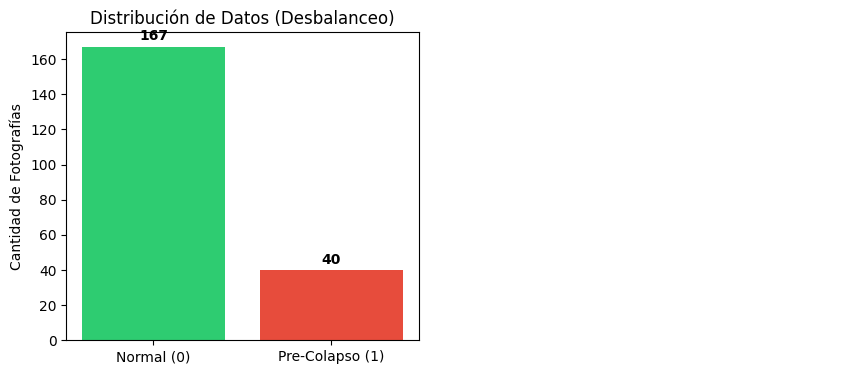

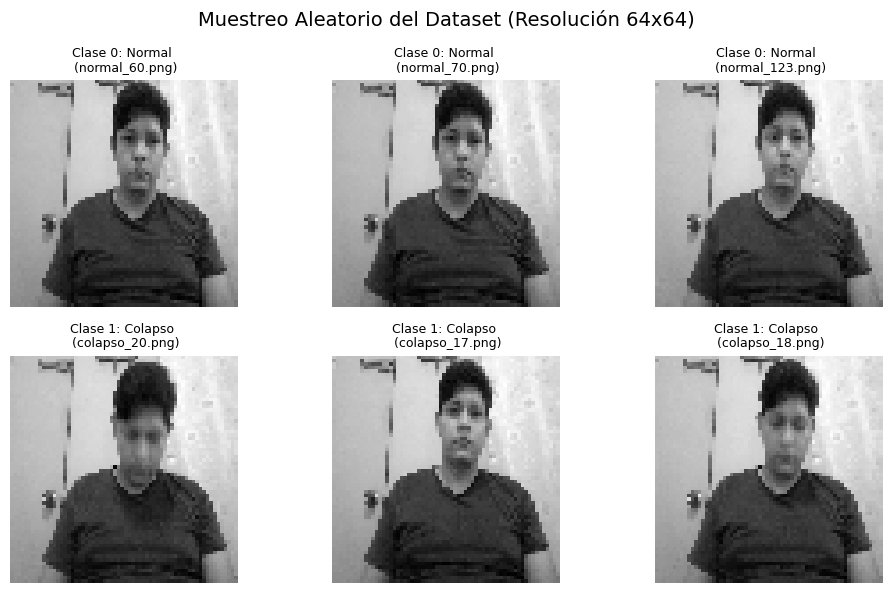

In [3]:
# CELDA: Análisis Exploratorio y Visualización del Dataset
import os
import cv2
import random
import matplotlib.pyplot as plt

ruta_normal = 'Dataset_Posturas/0_Normal'
ruta_colapso = 'Dataset_Posturas/1_Colapso'

# 1. Contar los archivos en las carpetas
archivos_normal = os.listdir(ruta_normal)
archivos_colapso = os.listdir(ruta_colapso)

cant_normal = len(archivos_normal)
cant_colapso = len(archivos_colapso)

print(f"Total Normales: {cant_normal}")
print(f"Total Pre-Colapso: {cant_colapso}")

# ==========================================
# GRÁFICA 1: Distribución de Clases (Barras)
# ==========================================
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
clases = ['Normal (0)', 'Pre-Colapso (1)']
cantidades = [cant_normal, cant_colapso]
colores = ['#2ecc71', '#e74c3c'] # Verde y Rojo

bars = plt.bar(clases, cantidades, color=colores)
plt.title('Distribución de Datos (Desbalanceo)')
plt.ylabel('Cantidad de Fotografías')

# Agregar el número exacto arriba de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, int(yval), ha='center', va='bottom', fontweight='bold')

# ==========================================
# GRÁFICA 2: Muestreo Visual de lo que ve la IA
# ==========================================
plt.subplot(1, 2, 2)
plt.axis('off') # Apagamos los ejes de esta subgráfica principal

# Vamos a mostrar 3 fotos de Normal y 3 de Colapso al azar
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle('Muestreo Aleatorio del Dataset (Resolución 64x64)', fontsize=14)

# Función rápida para cargar y mostrar
def mostrar_muestra(ruta_carpeta, lista_archivos, fila, titulo):
    # Elegir 3 archivos al azar
    muestras = random.sample(lista_archivos, min(3, len(lista_archivos)))
    for i, nombre_archivo in enumerate(muestras):
        img_path = os.path.join(ruta_carpeta, nombre_archivo)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # La leemos en escala de grises
        
        axes[fila, i].imshow(img, cmap='gray')
        axes[fila, i].set_title(f'{titulo} \n ({nombre_archivo})', fontsize=9)
        axes[fila, i].axis('off')

# Fila 0: Normales, Fila 1: Colapso
mostrar_muestra(ruta_normal, archivos_normal, 0, 'Clase 0: Normal')
mostrar_muestra(ruta_colapso, archivos_colapso, 1, 'Clase 1: Colapso')

plt.tight_layout()
plt.show()

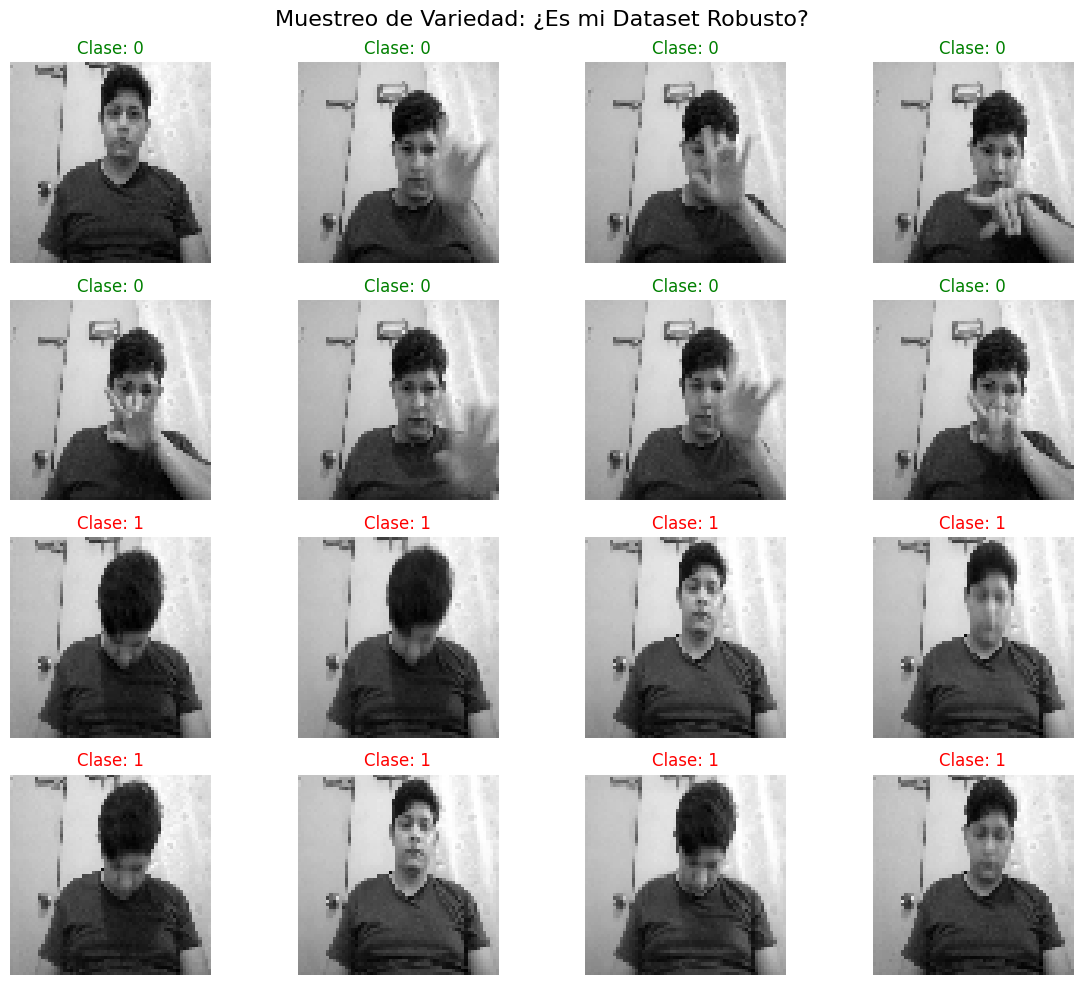

In [10]:
# CELDA: Visualización de Variedad del Dataset
import matplotlib.pyplot as plt
import numpy as np

def graficar_muestreo_variado(ruta_normal, ruta_colapso):
    fig, axes = plt.subplots(4, 4, figsize=(12, 10))
    fig.suptitle('Muestreo de Variedad: ¿Es mi Dataset Robusto?', fontsize=16)
    
    # Cargar 8 de cada una al azar
    for i in range(16):
        ax = axes[i//4, i%4]
        clase = 0 if i < 8 else 1
        ruta = ruta_normal if clase == 0 else ruta_colapso
        img_name = random.choice(os.listdir(ruta))
        img = cv2.imread(os.path.join(ruta, img_name), cv2.IMREAD_GRAYSCALE)
        
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Clase: {clase}", color='green' if clase==0 else 'red')
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

graficar_muestreo_variado(ruta_normal, ruta_colapso)

In [4]:
# CELDA: Recolector con Soporte de Control Bluetooth y Auto-indexado
import cv2
import os
import glob
import pygame

# 1. Inicializar el motor del control (Pygame)
pygame.init()
pygame.joystick.init()

control_conectado = False
if pygame.joystick.get_count() > 0:
    joystick = pygame.joystick.Joystick(0)
    joystick.init()
    control_conectado = True
    print(f"¡Control detectado con éxito!: {joystick.get_name()}")
else:
    print("⚠️ No se detectó ningún control Bluetooth. El sistema funcionará solo con teclado.")

# 2. Definir y crear rutas
ruta_normal = 'Dataset_Posturas/0_Normal'
ruta_colapso = 'Dataset_Posturas/1_Colapso'

os.makedirs(ruta_normal, exist_ok=True)
os.makedirs(ruta_colapso, exist_ok=True)

# Buscar la última foto para no sobrescribir nada
def obtener_ultimo_indice(ruta_carpeta, prefijo):
    archivos = glob.glob(os.path.join(ruta_carpeta, f"{prefijo}_*.png"))
    if not archivos:
        return 0
    indices = [int(arch.split('_')[-1].split('.png')[0]) for arch in archivos]
    return max(indices) + 1

contador_normal = obtener_ultimo_indice(ruta_normal, "normal")
contador_colapso = obtener_ultimo_indice(ruta_colapso, "colapso")

# 3. Iniciar la cámara web
cap = cv2.VideoCapture(0)

print("\n=== RECOLECTOR INICIADO (MANDO BLUETOOTH EN LAZO) ===")
print(f"-> Continuando desde foto Normal #{contador_normal}")
print(f"-> Continuando desde foto Colapso #{contador_colapso}\n")
print("DISPARADORES:")
print("  - FOTOS NORMALES: Tecla '0' en laptop  O  Botón 0 (A/X) en el control.")
print("  - FOTOS COLAPSO:  Tecla '1' en laptop  O  Botón 1 (B/O) en el control.")
print("  - SALIR:          Tecla 'q' en laptop.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    cv2.imshow('Captura Remota con Mando Bluetooth', frame)
    
    # Escuchar teclado
    key = cv2.waitKey(1) & 0xFF
    
    # Escuchar Control Bluetooth
    disparar_normal_control = False
    disparar_colapso_control = False
    
    if control_conectado:
        pygame.event.pump() # Actualizar los eventos del control
        
        # Revisar si el botón 0 o 1 están siendo presionados
        if joystick.get_button(0): 
            disparar_normal_control = True
        if joystick.get_button(1): 
            disparar_colapso_control = True

    # Redimensionar la foto para la RNAC (64x64)
    img_resized = cv2.resize(frame, (64, 64))

    # Lógica de guardado para clase 0 (Normal)
    if key == ord('0') or disparar_normal_control:
        ruta = os.path.join(ruta_normal, f'normal_{contador_normal}.png')
        cv2.imwrite(ruta, img_resized)
        print(f"[OK] Foto Normal #{contador_normal} guardada.")
        contador_normal += 1
        if disparar_normal_control: cv2.waitKey(150) # Delay para evitar ráfagas masivas con el control

    # Lógica de guardado para clase 1 (Colapso)
    elif key == ord('1') or disparar_colapso_control:
        ruta = os.path.join(ruta_colapso, f'colapso_{contador_colapso}.png')
        cv2.imwrite(ruta, img_resized)
        print(f"[ALERTA] Foto Colapso #{contador_colapso} guardada.")
        contador_colapso += 1
        if disparar_colapso_control: cv2.waitKey(150) # Delay para evitar ráfagas masivas con el control
        
    elif key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
pygame.quit()

print("\n=== PROCESO TERMINADO ===")
print(f"Total en carpeta Normal: {len(os.listdir(ruta_normal))}")
print(f"Total en carpeta Colapso: {len(os.listdir(ruta_colapso))}")

¡Control detectado con éxito!: Nintendo Switch Pro Controller

=== RECOLECTOR INICIADO (MANDO BLUETOOTH EN LAZO) ===
-> Continuando desde foto Normal #167
-> Continuando desde foto Colapso #40

DISPARADORES:
  - FOTOS NORMALES: Tecla '0' en laptop  O  Botón 0 (A/X) en el control.
  - FOTOS COLAPSO:  Tecla '1' en laptop  O  Botón 1 (B/O) en el control.
  - SALIR:          Tecla 'q' en laptop.
[OK] Foto Normal #167 guardada.
[OK] Foto Normal #168 guardada.
[OK] Foto Normal #169 guardada.
[OK] Foto Normal #170 guardada.
[OK] Foto Normal #171 guardada.
[OK] Foto Normal #172 guardada.
[OK] Foto Normal #173 guardada.
[OK] Foto Normal #174 guardada.
[OK] Foto Normal #175 guardada.
[OK] Foto Normal #176 guardada.
[OK] Foto Normal #177 guardada.
[OK] Foto Normal #178 guardada.
[OK] Foto Normal #179 guardada.
[OK] Foto Normal #180 guardada.
[OK] Foto Normal #181 guardada.
[OK] Foto Normal #182 guardada.
[ALERTA] Foto Colapso #40 guardada.
[ALERTA] Foto Colapso #41 guardada.
[ALERTA] Foto Colapso